In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [11]:
path = r"C:\kuliah\tubes STD & Algo\Churn_Modelling.csv"

df = pd.read_csv(path)

In [12]:
class FeatureEngineering:

    def __init__(self, df):
        self.df = df.copy()

    def run(self):

        self.df["Churn_Label"] = self.df["Exited"].map({
            0:"Non-Churn",
            1:"Churn"
        })

        # Country
        country = (
            self.df.groupby("Geography")["Exited"]
            .mean()
            .reset_index()
        )

        country.columns = [
            "Geography",
            "Country_Churn_Rate"
        ]

        self.df = self.df.merge(country,on="Geography")

        self.df["Country_NonChurn_Rate"] = (
            1-self.df["Country_Churn_Rate"]
        )

        # Gender

        gender = (
            self.df.groupby("Gender")["Exited"]
            .mean()
            .reset_index()
        )

        gender.columns=[
            "Gender",
            "Gender_Churn_Rate"
        ]

        self.df=self.df.merge(gender,on="Gender")

        # Active

        active=(
            self.df.groupby("IsActiveMember")["Exited"]
            .mean()
            .reset_index()
        )

        active.columns=[
            "IsActiveMember",
            "Active_Churn_Rate"
        ]

        self.df=self.df.merge(active,on="IsActiveMember")

        # Card

        card=(
            self.df.groupby("HasCrCard")["Exited"]
            .mean()
            .reset_index()
        )

        card.columns=[
            "HasCrCard",
            "Card_Churn_Rate"
        ]

        self.df=self.df.merge(card,on="HasCrCard")

        # Product

        product=(
            self.df.groupby("NumOfProducts")["Exited"]
            .mean()
            .reset_index()
        )

        product.columns=[
            "NumOfProducts",
            "Product_Churn_Rate"
        ]

        self.df=self.df.merge(product,on="NumOfProducts")

        return self.df

In [13]:
fe = FeatureEngineering(df)

df = fe.run()

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,IsActiveMember,EstimatedSalary,Exited,Churn_Label,Country_Churn_Rate,Country_NonChurn_Rate,Gender_Churn_Rate,Active_Churn_Rate,Card_Churn_Rate,Product_Churn_Rate
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,1,101348.88,1,Churn,0.161548,0.838452,0.250715,0.142691,0.201843,0.277144
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,1,112542.58,0,Non-Churn,0.166734,0.833266,0.250715,0.142691,0.208149,0.277144
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,0,113931.57,1,Churn,0.161548,0.838452,0.250715,0.268509,0.201843,0.827068
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0,93826.63,0,Non-Churn,0.161548,0.838452,0.250715,0.268509,0.208149,0.075817
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,1,79084.10,0,Non-Churn,0.166734,0.833266,0.250715,0.142691,0.201843,0.277144


In [14]:
class EDAAnalysis:

    def __init__(self,df):

        self.df=df

    def dataset_info(self):

        print("="*60)
        print("SHAPE")
        print("="*60)
        print(self.df.shape)

        print()

        print("="*60)
        print("INFO")
        print("="*60)
        print(self.df.info())

        print()

        print("="*60)
        print("DTYPES")
        print("="*60)
        print(self.df.dtypes)

    def missing_value(self):

        missing=pd.DataFrame({

            "Missing Value":self.df.isnull().sum(),
            "Percentage (%)":round(
                self.df.isnull().mean()*100,2
            )

        })

        display(missing)

    def descriptive(self):

        display(self.df.describe().T)

    def churn_summary(self):

        total=len(self.df)

        churn=self.df["Exited"].sum()

        non=total-churn

        print(f"Total Customer : {total}")
        print(f"Total Churn : {churn}")
        print(f"Total Non Churn : {non}")
        print(f"Churn Rate : {churn/total:.2%}")
        print(f"Non Churn Rate : {non/total:.2%}")

    def summary_table(self,column):

        summary=(
            self.df.groupby(column)
            .agg(
                Total_Customer=("Exited","count"),
                Total_Churn=("Exited","sum")
            )
            .reset_index()
        )

        summary["Total_NonChurn"]=(
            summary["Total_Customer"]-
            summary["Total_Churn"]
        )

        summary["Churn_Rate"]=(
            summary["Total_Churn"]/
            summary["Total_Customer"]
        )

        summary["NonChurn_Rate"]=(
            summary["Total_NonChurn"]/
            summary["Total_Customer"]
        )

        display(summary)

        return summary

In [16]:
class Visualization:

    def __init__(self,df):

        self.df=df

        self.numeric=[
            "CreditScore",
            "Age",
            "Tenure",
            "Balance",
            "NumOfProducts",
            "EstimatedSalary"
        ]

    def overall_pie(self):

        total=self.df["Exited"].value_counts()

        plt.figure(figsize=(6,6))

        plt.pie(
            total,
            labels=["Non-Churn","Churn"],
            autopct="%1.2f%%",
            startangle=90
        )

        plt.title("Overall Churn Rate")
        plt.show()

    def pie_country(self):

        summary=(
            self.df.groupby("Geography")["Exited"]
            .mean()
        )

        plt.figure(figsize=(6,6))

        plt.pie(
            summary,
            labels=summary.index,
            autopct="%1.2f%%"
        )

        plt.title("Country Churn Rate")

        plt.show()

    def pie_gender(self):

        summary=(
            self.df.groupby("Gender")["Exited"]
            .mean()
        )

        plt.figure(figsize=(6,6))

        plt.pie(
            summary,
            labels=summary.index,
            autopct="%1.2f%%"
        )

        plt.title("Gender Churn Rate")

        plt.show()

    def bar_active(self):

        sns.barplot(
            data=self.df,
            x="IsActiveMember",
            y="Exited"
        )

        plt.title("Active Member")
        plt.show()

    def bar_card(self):

        sns.barplot(
            data=self.df,
            x="HasCrCard",
            y="Exited"
        )

        plt.title("Credit Card")
        plt.show()

    def distribution(self):

        for col in self.numeric:

            plt.figure(figsize=(8,4))

            sns.histplot(
                self.df[col],
                kde=True,
                bins=30
            )

            plt.title(col)

            plt.show()

    def distribution_churn(self):

        for col in self.numeric:

            plt.figure(figsize=(8,4))

            sns.histplot(
                data=self.df,
                x=col,
                hue="Churn_Label",
                kde=True
            )

            plt.title(col)

            plt.show()

    def boxplot(self):

        for col in self.numeric:

            plt.figure(figsize=(7,4))

            sns.boxplot(
                data=self.df,
                x="Churn_Label",
                y=col
            )

            plt.title(col)

            plt.show()

    def heatmap(self):

        corr=self.df[self.numeric+["Exited"]].corr()

        plt.figure(figsize=(10,8))

        sns.heatmap(
            corr,
            annot=True,
            cmap="RdBu_r"
        )

        plt.title("Correlation Heatmap")

        plt.show()

    def triangle_heatmap(self):

        corr=self.df[self.numeric+["Exited"]].corr()

        mask=np.triu(np.ones_like(corr,dtype=bool))

        plt.figure(figsize=(10,8))

        sns.heatmap(
            corr,
            mask=mask,
            annot=True,
            cmap="coolwarm"
        )

        plt.title("Triangle Heatmap")

        plt.show()

    def pairplot(self):

        sns.pairplot(
            self.df[
                [
                    "CreditScore",
                    "Age",
                    "Balance",
                    "EstimatedSalary",
                    "Exited"
                ]
            ],
            hue="Exited",
            diag_kind="kde"
        )

        plt.show()

SHAPE
(10000, 21)

INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RowNumber              10000 non-null  int64  
 1   CustomerId             10000 non-null  int64  
 2   Surname                10000 non-null  str    
 3   CreditScore            10000 non-null  int64  
 4   Geography              10000 non-null  str    
 5   Gender                 10000 non-null  str    
 6   Age                    10000 non-null  int64  
 7   Tenure                 10000 non-null  int64  
 8   Balance                10000 non-null  float64
 9   NumOfProducts          10000 non-null  int64  
 10  HasCrCard              10000 non-null  int64  
 11  IsActiveMember         10000 non-null  int64  
 12  EstimatedSalary        10000 non-null  float64
 13  Exited                 10000 non-null  int64  
 14  Churn_Label            10000 non-null  str

,Missing Value,Percentage (%)
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.000000e+00,2.500750e+03,5.000500e+03,7.500250e+03,1.000000e+04
CustomerId,10000.0,1.569094e+07,71936.186123,1.556570e+07,1.562853e+07,1.569074e+07,1.575323e+07,1.581569e+07
CreditScore,10000.0,6.505288e+02,96.653299,3.500000e+02,5.840000e+02,6.520000e+02,7.180000e+02,8.500000e+02
Age,10000.0,3.892180e+01,10.487806,1.800000e+01,3.200000e+01,3.700000e+01,4.400000e+01,9.200000e+01
Tenure,10000.0,5.012800e+00,2.892174,0.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,1.000000e+01
Balance,10000.0,7.648589e+04,62397.405202,0.000000e+00,0.000000e+00,9.719854e+04,1.276442e+05,2.508981e+05
NumOfProducts,10000.0,1.530200e+00,0.581654,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
HasCrCard,10000.0,7.055000e-01,0.455840,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,1.158000e+01,5.100211e+04,1.001939e+05,1.493882e+05,1.999925e+05


Total Customer : 10000
Total Churn : 2037
Total Non Churn : 7963
Churn Rate : 20.37%
Non Churn Rate : 79.63%


,Geography,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,France,5014,810,4204,0.161548,0.838452
1,Germany,2509,814,1695,0.324432,0.675568
2,Spain,2477,413,2064,0.166734,0.833266


,Gender,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,Female,4543,1139,3404,0.250715,0.749285
1,Male,5457,898,4559,0.164559,0.835441


,IsActiveMember,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,0,4849,1302,3547,0.268509,0.731491
1,1,5151,735,4416,0.142691,0.857309


,HasCrCard,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,0,2945,613,2332,0.208149,0.791851
1,1,7055,1424,5631,0.201843,0.798157


,NumOfProducts,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,1,5084,1409,3675,0.277144,0.722856
1,2,4590,348,4242,0.075817,0.924183
2,3,266,220,46,0.827068,0.172932
3,4,60,60,0,1.000000,0.000000


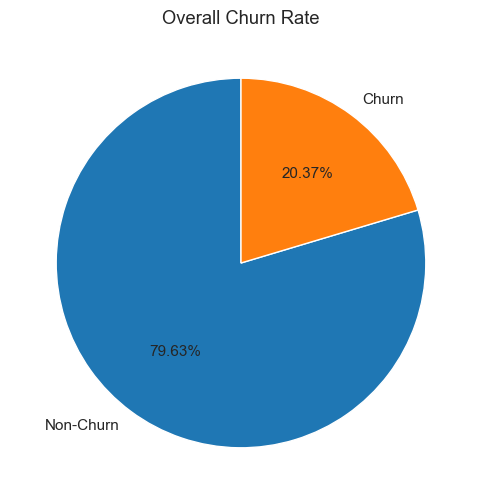

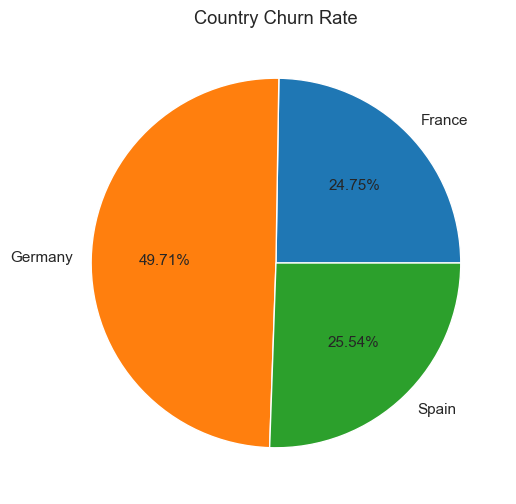

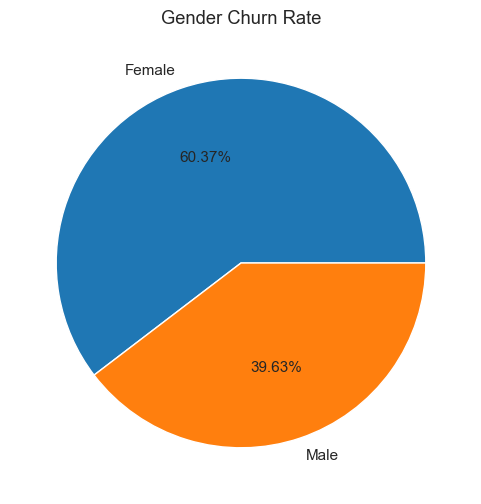

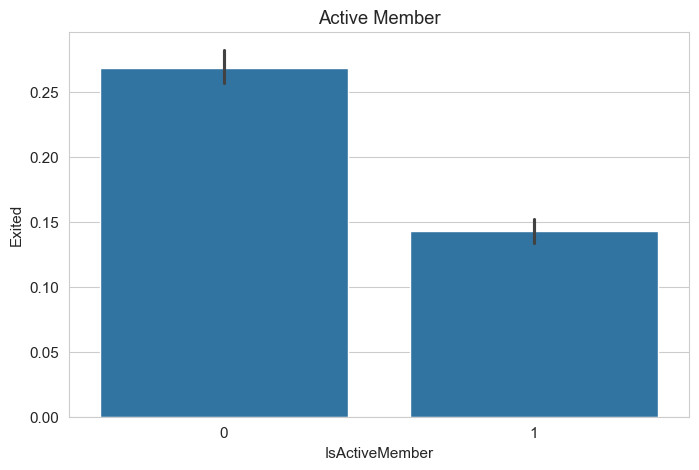

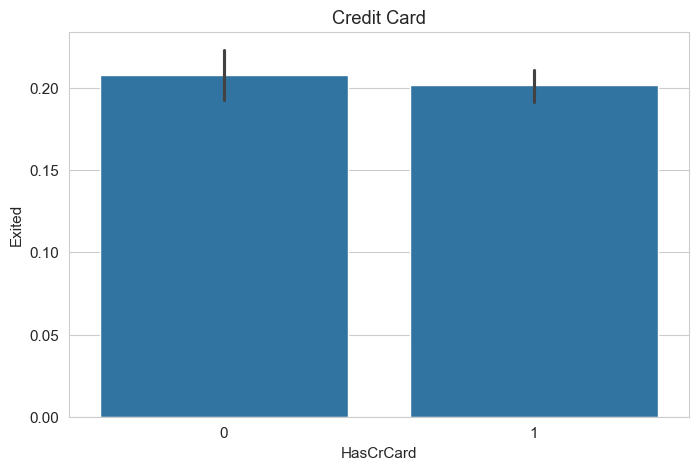

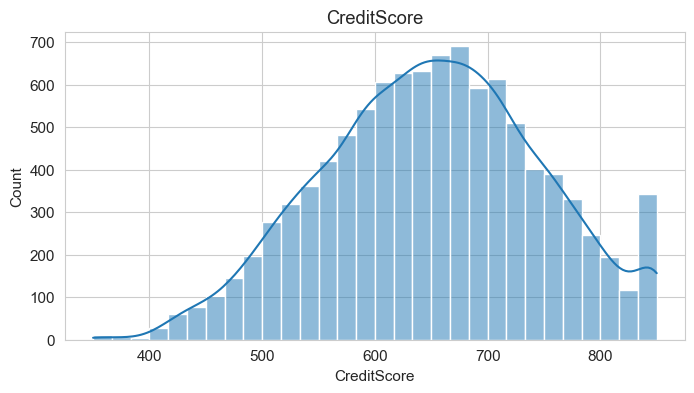

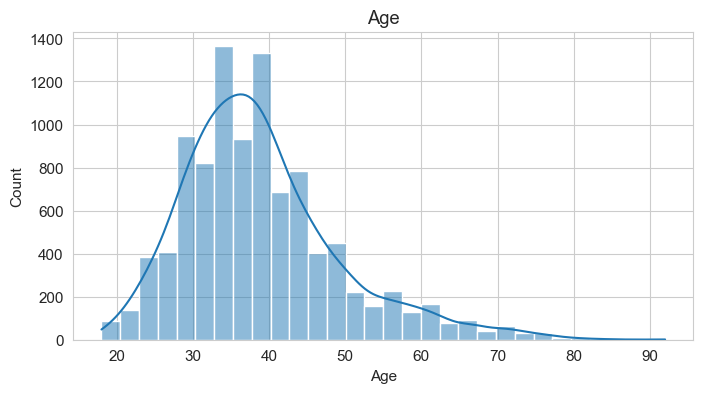

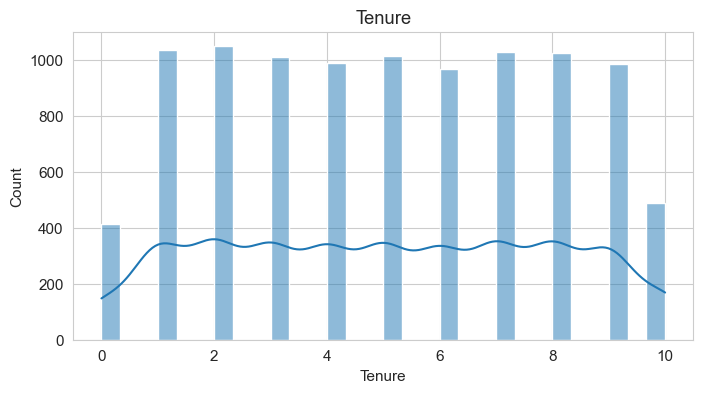

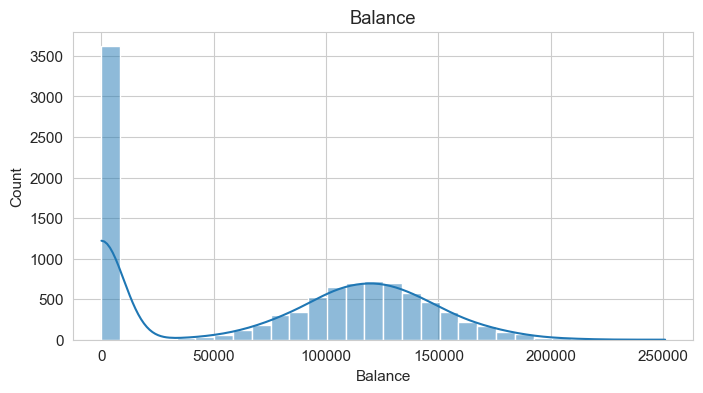

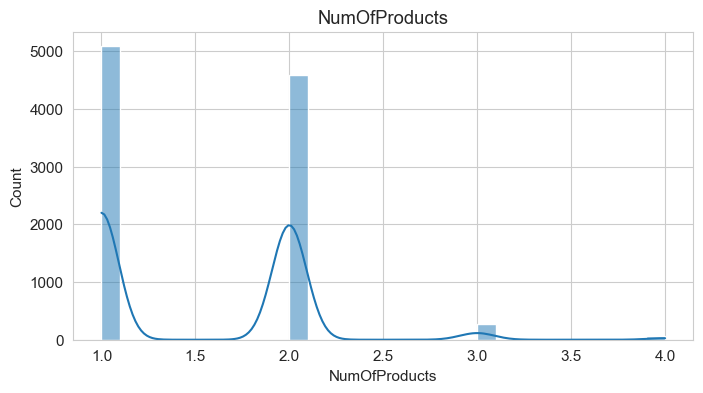

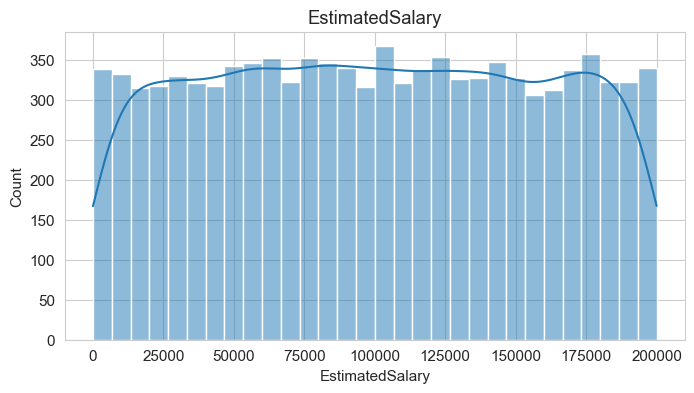

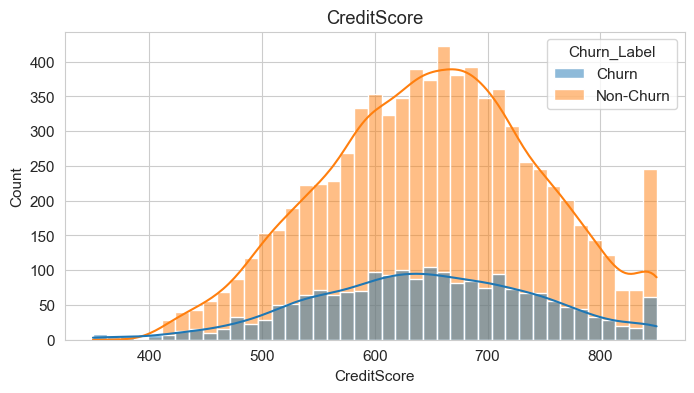

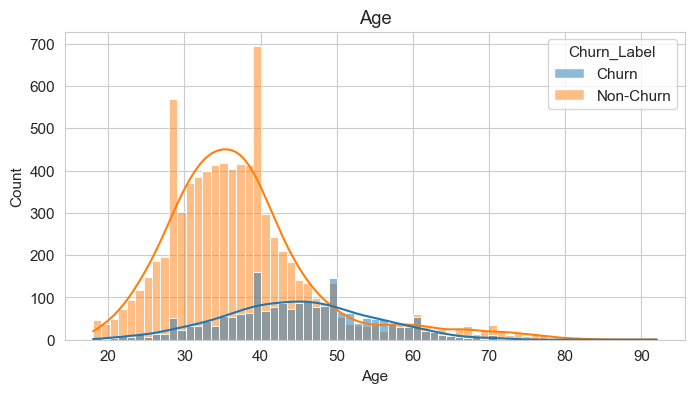

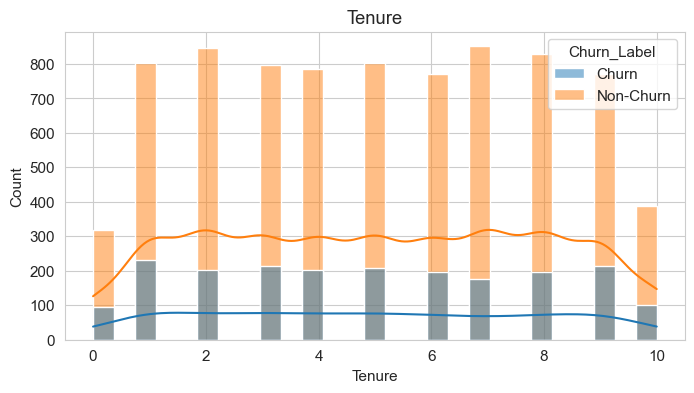

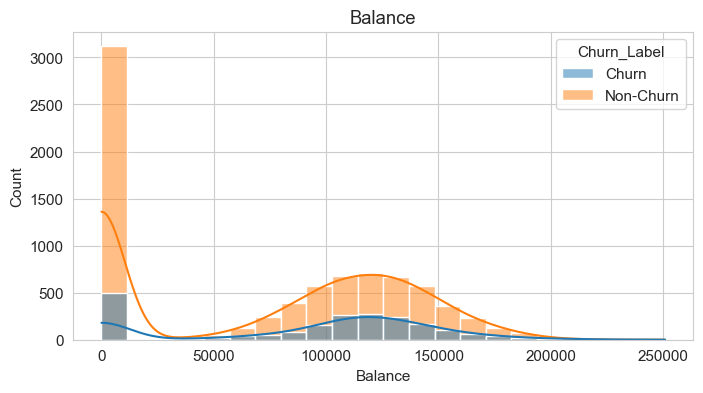

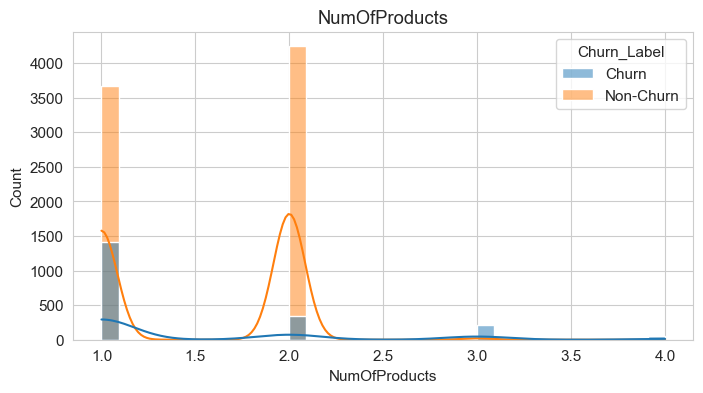

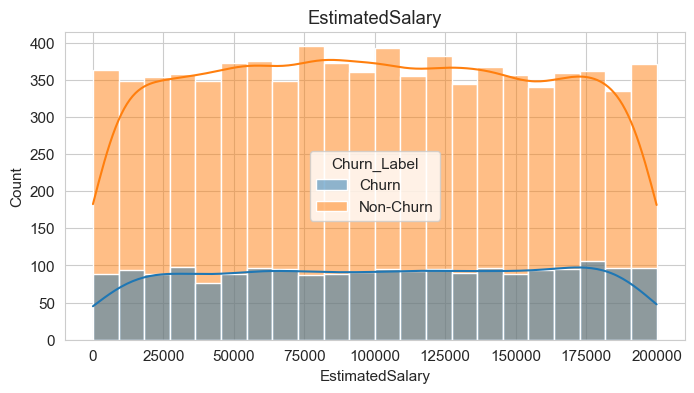

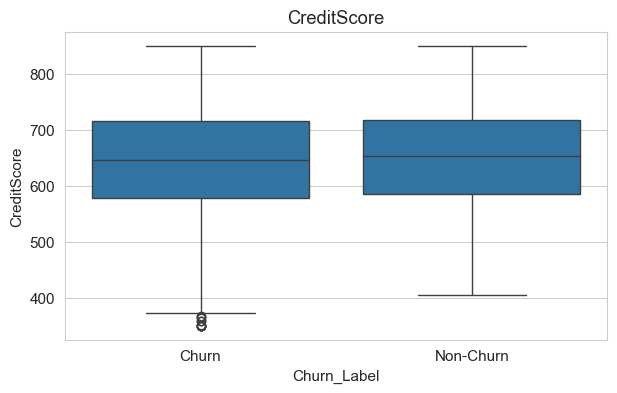

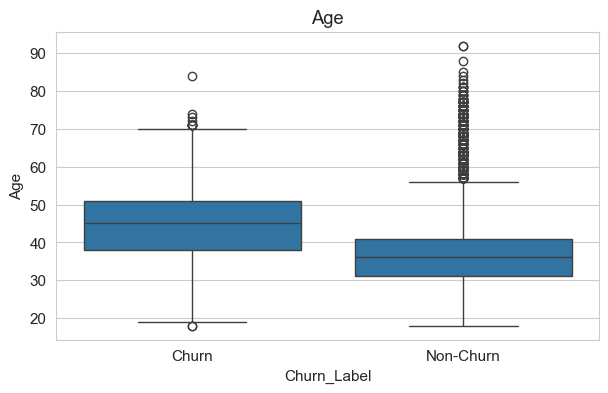

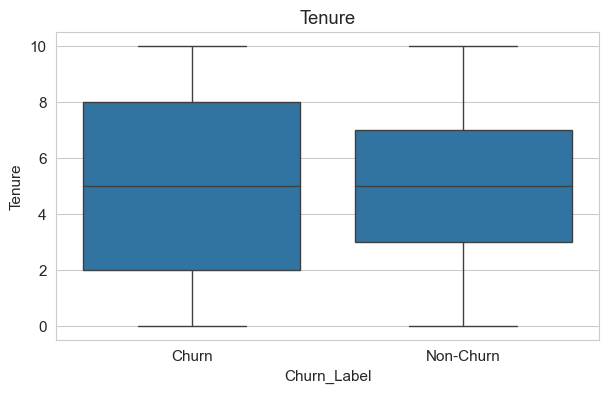

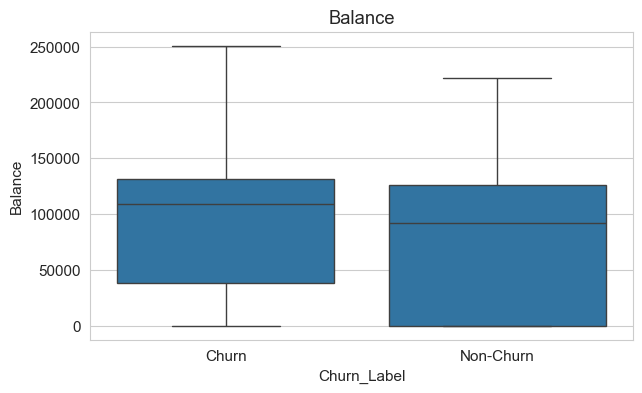

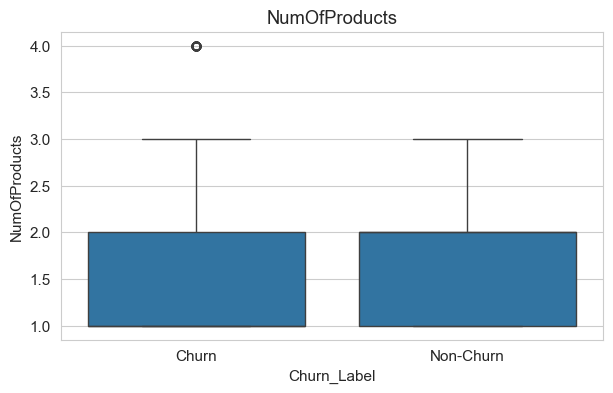

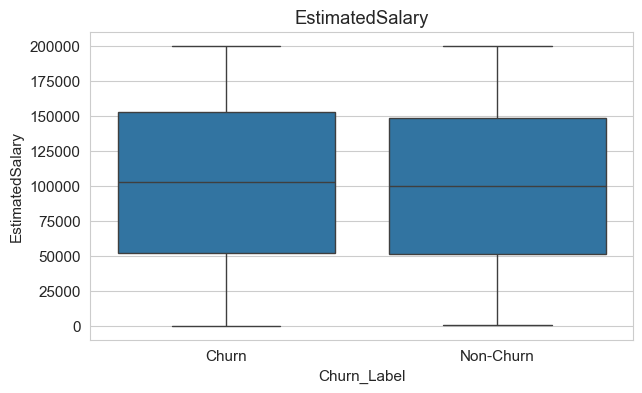

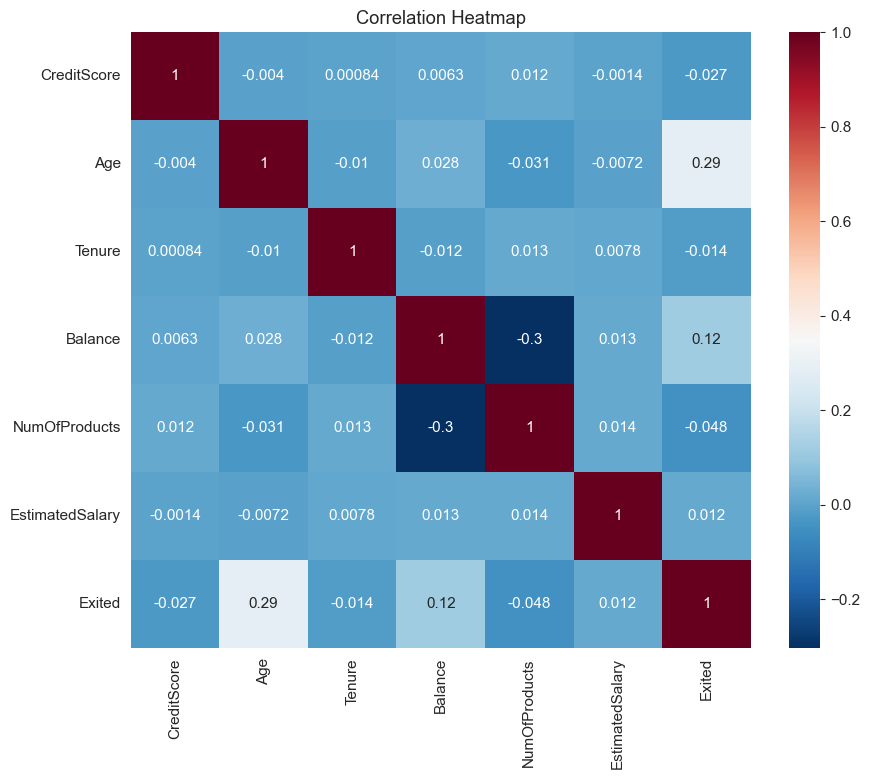

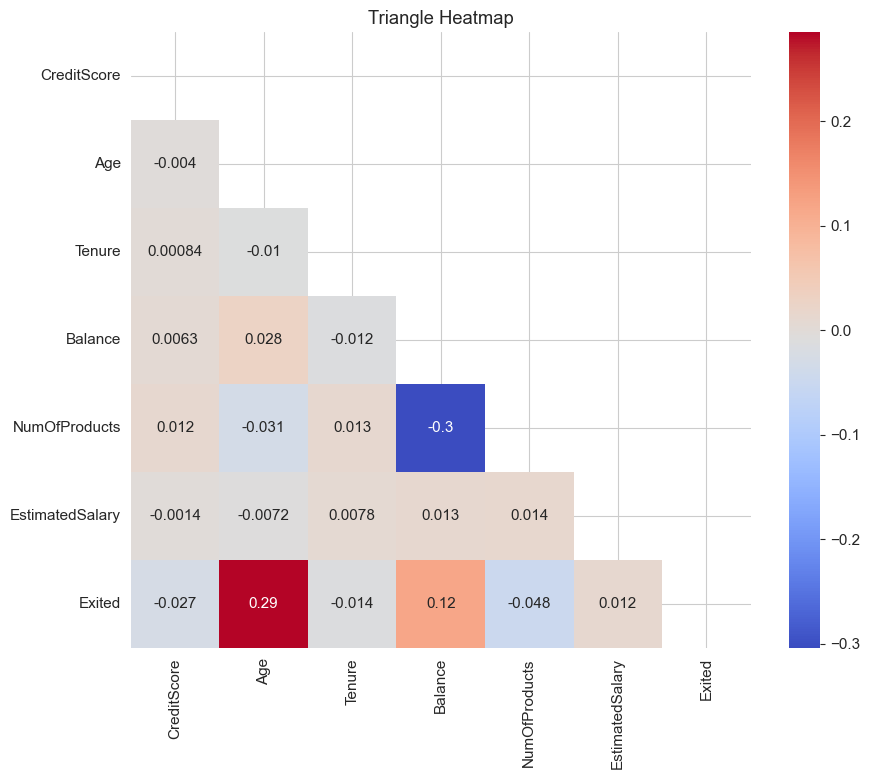

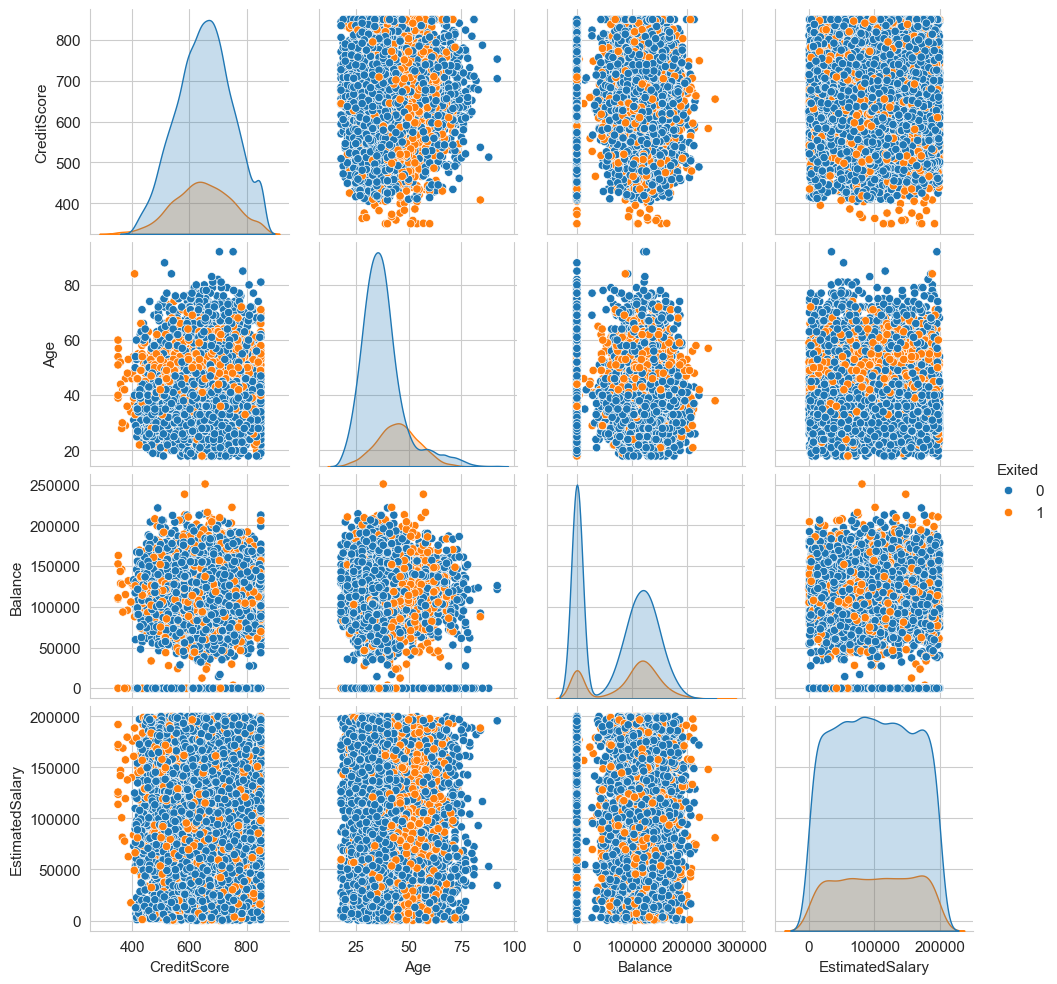

In [17]:
if __name__ == "__main__":

    eda = EDAAnalysis(df)

    analysis = [

        eda.dataset_info,
        eda.missing_value,
        eda.descriptive,
        eda.churn_summary,

        lambda: eda.summary_table("Geography"),
        lambda: eda.summary_table("Gender"),
        lambda: eda.summary_table("IsActiveMember"),
        lambda: eda.summary_table("HasCrCard"),
        lambda: eda.summary_table("NumOfProducts")

    ]

    for func in analysis:
        func()

    visual = Visualization(df)

    visuals = [

        visual.overall_pie,
        visual.pie_country,
        visual.pie_gender,
        visual.bar_active,
        visual.bar_card,
        visual.distribution,
        visual.distribution_churn,
        visual.boxplot,
        visual.heatmap,
        visual.triangle_heatmap,
        visual.pairplot

    ]

    for graph in visuals:
        graph()